In [45]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from pathlib import Path
import ast
import matplotlib.dates as mdates
from datetime import timedelta
myFmt = mdates.DateFormatter('%H:%M:%S') 


In [136]:
def stat_reader(fname):
    f=open(fname)
    try:
        stat_dict = ast.literal_eval(f.readlines()[-2].strip()) #with the journalctl line
    except Exception as e:
        stat_dict="failed_rank"
    # print(stat_dict)
    return stat_dict

def tf_calc(w):
    y=0
    if w < 8:
        y = 0.157 - 0.004*27 + 0.075*w
    else:
        y = 0.667 - 0.008*27 + 0.023*w
    return y

def cdf_gen(arr, e=False):
    sorted_arr = sorted(arr)
    y=[]
    for x in range(len(sorted_arr)):
        counter = len(sorted_arr[x+1:]) if e else x+1
        y.append(counter/len(sorted_arr))
    return sorted_arr, y 


def filter_warmups(full_path, arrs, valid_cores=1, exp_len=11):
    # print(arrs)
    c=0
    msg=''
    marked = []
    for ind, _ in enumerate(arrs):
        arrs[ind]=[i for i in arrs[ind] if i > 0]
        arrs[ind]=[i for i in arrs[ind] if i < min(arrs[ind])*3]
        if c < valid_cores:
            # assert len(arrs[ind]) == exp_len, f"{full_path} doesn't have valid runs?"
            if len(arrs[ind]) != exp_len:
                msg = f"{full_path} doesn't have valid runs?"
                marked.append(ind)

            c+=1
    correction = max([sum(arrs[ind]) for ind in range(len(arrs)) if ind not in marked])/1000
    return (arrs, correction, msg)






/Users/animeshnd/model_splitting/logs/single_group_heat//bramble-4-1/vit_modules/1_concurrency_level/1/10_4/speed_chronosbramble-4-1-38_7.log doesn't have valid runs?
/Users/animeshnd/model_splitting/logs/single_group_heat//bramble-4-1/vit_modules/10_concurrency_level/1/10_4/speed_chronosbramble-4-1-12_3.log doesn't have valid runs?
/Users/animeshnd/model_splitting/logs/single_group_heat//bramble-4-1/vit_modules/10_concurrency_level/1/10_4/speed_chronosbramble-4-1-14_3.log doesn't have valid runs?
/Users/animeshnd/model_splitting/logs/single_group_heat//bramble-4-1/vit_modules/10_concurrency_level/1/10_4/speed_chronosbramble-4-1-25_3.log doesn't have valid runs?
/Users/animeshnd/model_splitting/logs/single_group_heat//bramble-4-1/vit_modules/10_concurrency_level/1/10_4/speed_chronosbramble-4-1-29_3.log doesn't have valid runs?
/Users/animeshnd/model_splitting/logs/single_group_heat//bramble-4-1/vit_modules/10_concurrency_level/1/10_4/speed_chronosbramble-4-1-30_3.log doesn't have valid

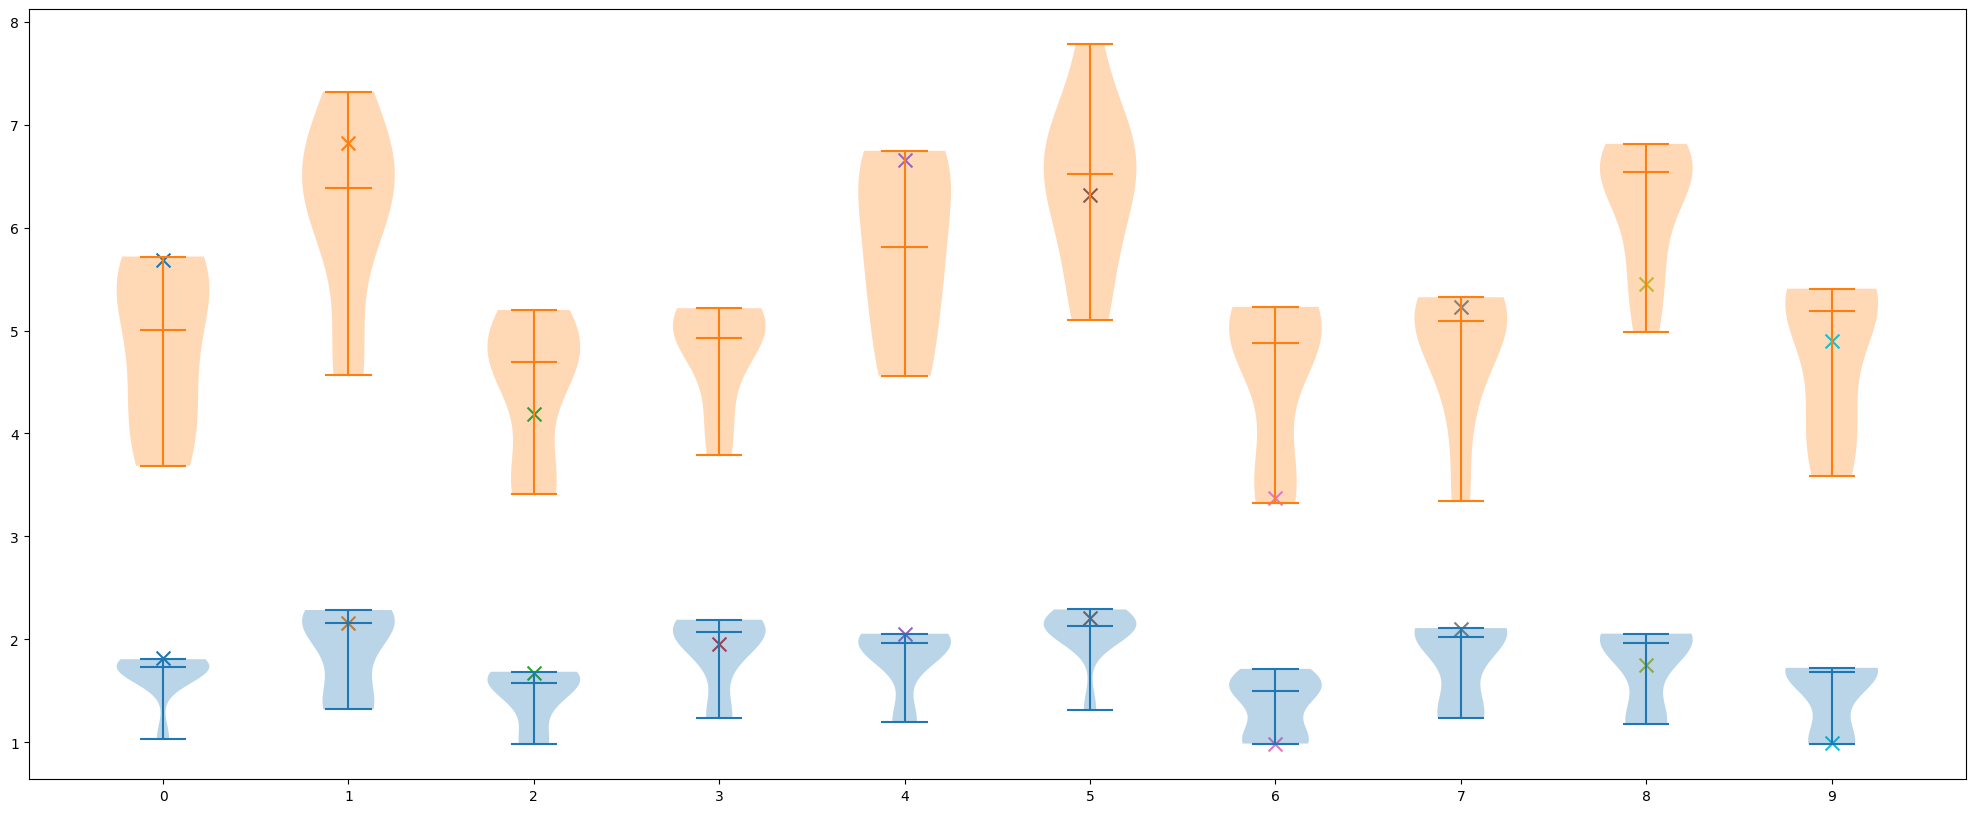

In [145]:
#1 core analysis of single_group_vit
# /Users/animeshnd/model_splitting/logs/single_group_heat/bramble-4-5/vit_modules/1_concurrency_level/1/3_1/speed_chronosbramble-4-5-9_2.log
cons = [1,10]
model="vit"
split_type="modules"
# cores=[1,2,3,4]
cores=[1,4]
# cores=[4]
pdu_tag="bramble-4-1"
# pdu_tag="bramble-2-1"
prefix = "/Users/animeshnd/model_splitting/logs/single_group_heat/"
# worlds = [5]#,10]
worlds = [10]
comp_times={core:{con:{k:{r:[] for r in range(k)} for k in worlds} for con in cons} for core in cores}
for con in cons:
    for world in worlds:
        for core in cores:
            for r in range(world):
                for dev in range(1,42):
                    full_path = f"{prefix}/{pdu_tag}/{model}_{split_type}/{con}_concurrency_level/1/{world}_{core}/speed_chronos{pdu_tag}-{dev}_{r}.log"
                    if Path.is_file(Path(full_path)):
                        m = stat_reader(full_path)
                        if "fail" in m:
                            print(full_path)
                            continue
                        warmups = m["warmup"][0]
                        #warmup is 4 cores, so 4 arrays, each with len == number of iters + 1 (1==warmup iter)
                        #if we used all 4 cores -> each array should be these lens -> if an array has 0s or -ve values -> bad array!
                        # try:
                        try:
                            warmups, corr, msg = filter_warmups(full_path, warmups, valid_cores=core, exp_len=11)
                        
                            if len(msg)>0:
                                print(msg)
                                m["comp_times"][0] = corr
                        except Exception as e:
                        #     # m["comp_times"][0]
                            # print(full_path)
                            continue
                            # pass
                        comp_times[core][con][world][r].append(m["comp_times"][0]/10)

# colors=["blue", "orange", "green", "red", "purple", "brown", "pink", "grey"]
axs_map={}
for k in comp_times[1][1]:
    fig, axs = plt.subplots(figsize=(25,10))
    axs_map[k]=axs
    axs=axs_map[k]
    for r in comp_times[1][1][k]:
        # print(k ,r)
        # print(comp_times[1][k][r])
        axs.scatter([r]*len(comp_times[1][1][k][r]), comp_times[1][1][k][r], marker="x", s=100)
        
        # axs.violin()
        # print(comp_times[k][r])
        # x,y = cdf_gen([round(i,3) for i in comp_times[k][r]])
        # axs.plot(x,y, label=f"rank_{r}")

for k in comp_times[1][10]:
    axs=axs_map[k]
    # for r in comp_times[10][k]:
        # print(comp_times[10][k])
    dist = [v for v in comp_times[1][10][k].values()]
    dist = [[0] if len(d)==0 else d for d in dist] 
    # print(dist)
    axs.violinplot(dist, positions=np.arange(0,k, 1), showmedians=True)
    axs.set_xticks(np.arange(0,k, 1))


for k in comp_times[4][10]:
    axs=axs_map[k]
    dist = [v for v in comp_times[4][10][k].values()]
    print(dist)
    dist = [[0] if len(d)==0 else d for d in dist] 
    # for r in comp_times[10][k]:
        # print(comp_times[10][k])
    axs.violinplot(dist, positions=np.arange(0,k, 1), showmedians=True)
    # axs.set_xticks(np.arange(0,k, 1))

for k in comp_times[4][1]:
    axs=axs_map[k]
    for r in comp_times[4][1][k]:
        axs.scatter([r]*len(comp_times[4][1][k][r]), comp_times[4][1][k][r], marker="x", s=100)
    # for r in comp_times[10][k]:
        # print(comp_times[10][k])
    # axs.violinplot([v for v in comp_times[4][10][k].values()], positions=np.arange(0,k, 1), showmedians=True)
    # axs.set_xticks(np.arange(0,k, 1))
